In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *
import emcee

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

# Misure di spessore e rate della bilancia

In [4]:
# caricamento dati
data_folder = os.path.join(base_img_folder, folder_selector.value)
image_folder = os.path.join(data_folder, "images")
bilancia_file = os.path.join(data_folder, "data", "points.txt")

bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(bilancia_file)
bilancia_trel = np.array(bilancia_timestamps) - bilancia_timestamps[0]  # secondi dall'inizio della misura

# convertiamo in array numpy per comodità
bilancia_thicknesses = np.array(bilancia_thicknesses)   # spessori letti dalla bilancia
bilancia_rates = np.array(bilancia_rates)   # rate di deposizione letti dalla bilancia

# tagliamo i primi 100 secondi, hanno spessore costante
start_cut_time = 100
cut_mask = bilancia_trel >= start_cut_time
bilancia_trel = bilancia_trel[cut_mask]
bilancia_thicknesses = bilancia_thicknesses[cut_mask]
bilancia_rates = bilancia_rates[cut_mask]

In [5]:
# fit lineare per ottenere la funzione di spessore in funzione del tempo
fitted_rate, thickness_offset = np.polyfit(bilancia_trel, bilancia_thicknesses, 1)  # rate medio e offset per spessore vs tempo
spessori_func = lambda t: fitted_rate*t + thickness_offset  # funzione di spessore in funzione del tempo, più comoda rispetto a portarsi dietro tutti i dati della bilancia
fitted_rate_residues = bilancia_thicknesses - spessori_func(bilancia_trel)  # residui del fit lineare
fitted_rate_std = np.std(abs(fitted_rate_residues))  # deviazione standard dei residui del fit lineare
fitted_rate_std_offset = np.mean(abs(fitted_rate_residues))  # offset dei residui del fit lineare

# calcolo degli spessori come integrale dei rate
spessori_from_rate = np.cumsum(bilancia_rates * np.diff(np.concatenate(([0], bilancia_trel))), axis=0)  # integrale dei rate per ottenere lo spessore, con np.diff per calcolare i delta_t tra i campioni

print(f"Spessore finale da bilancia: {bilancia_thicknesses[-1]:.6f} m")
print(f"Spessore finale da rate: {spessori_from_rate[-1]:.6f} m")
print(f"Spessore finale da fit lineare: {spessori_func(bilancia_trel[-1]):.6f} m")

# fit lineare tra spessori da rate e spessori da bilancia per ottenere il fattore di scala e l'offset
non_zero_mask = (spessori_from_rate > 0) & (bilancia_thicknesses > 0)
unit_m, unit_q = np.polyfit(bilancia_thicknesses[non_zero_mask], spessori_from_rate[non_zero_mask], 1)
spessori_from_rate_scaled = unit_m * bilancia_thicknesses + unit_q  # spessori da rate scalati per confronto con spessori da bilancia

print(f"Fattore di scala per spessore da rate: {unit_m:.6f}")
print(f"Offset per spessore da rate: {unit_q:.6f}")


Spessore finale da bilancia: 4.836000 m
Spessore finale da rate: 2122.215020 m
Spessore finale da fit lineare: 4.970419 m
Fattore di scala per spessore da rate: 440.059544
Offset per spessore da rate: -6.667975


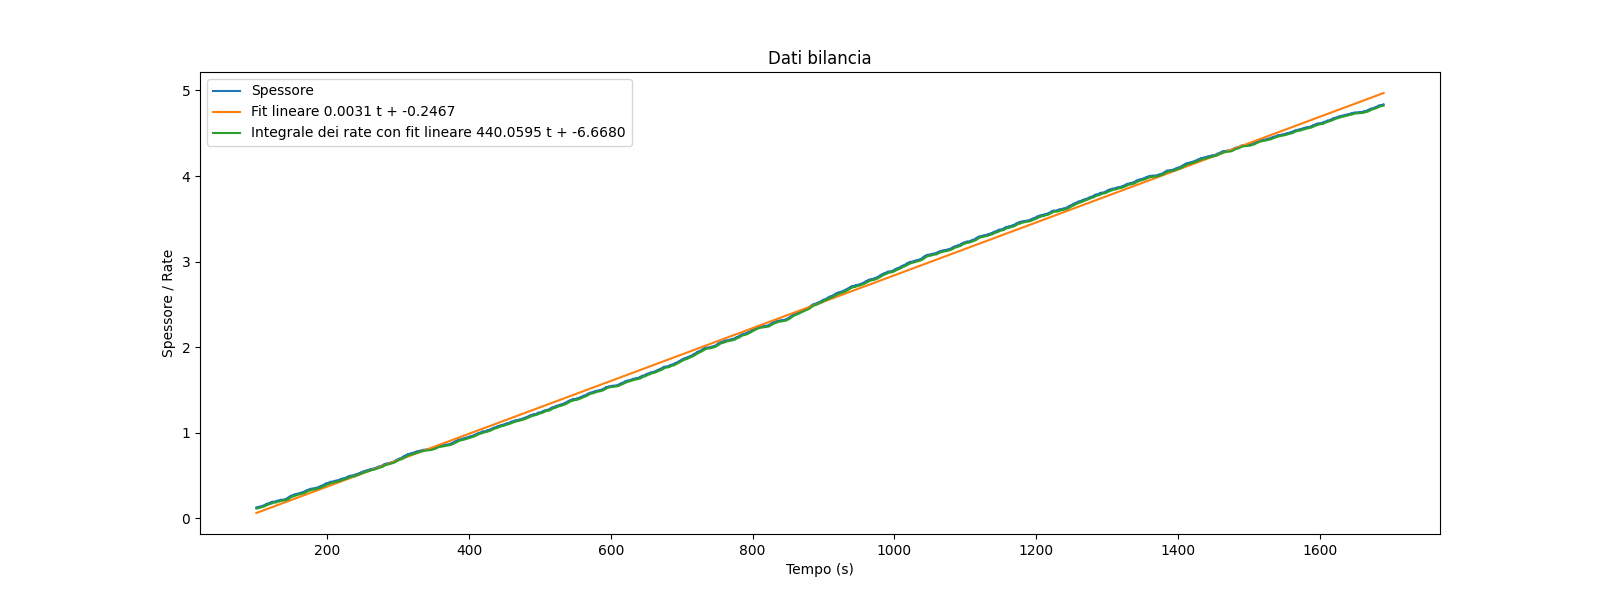

In [6]:
# plot dei dati della bilancia e confronto con spessori da rate e fit lineare
plt.figure(figsize=(16, 6))

plt.plot(bilancia_trel, bilancia_thicknesses, label='Spessore')
plt.plot(bilancia_trel, spessori_func(bilancia_trel), label=f'Fit lineare {fitted_rate:.4f} t + {thickness_offset:.4f}')
plt.plot(bilancia_trel, spessori_from_rate / unit_m, label=f'Integrale dei rate con fit lineare {unit_m:.4f} t + {unit_q:.4f}')

plt.xlabel('Tempo (s)')
plt.ylabel('Spessore / Rate')
plt.title('Dati bilancia')
plt.legend()

plt.show()

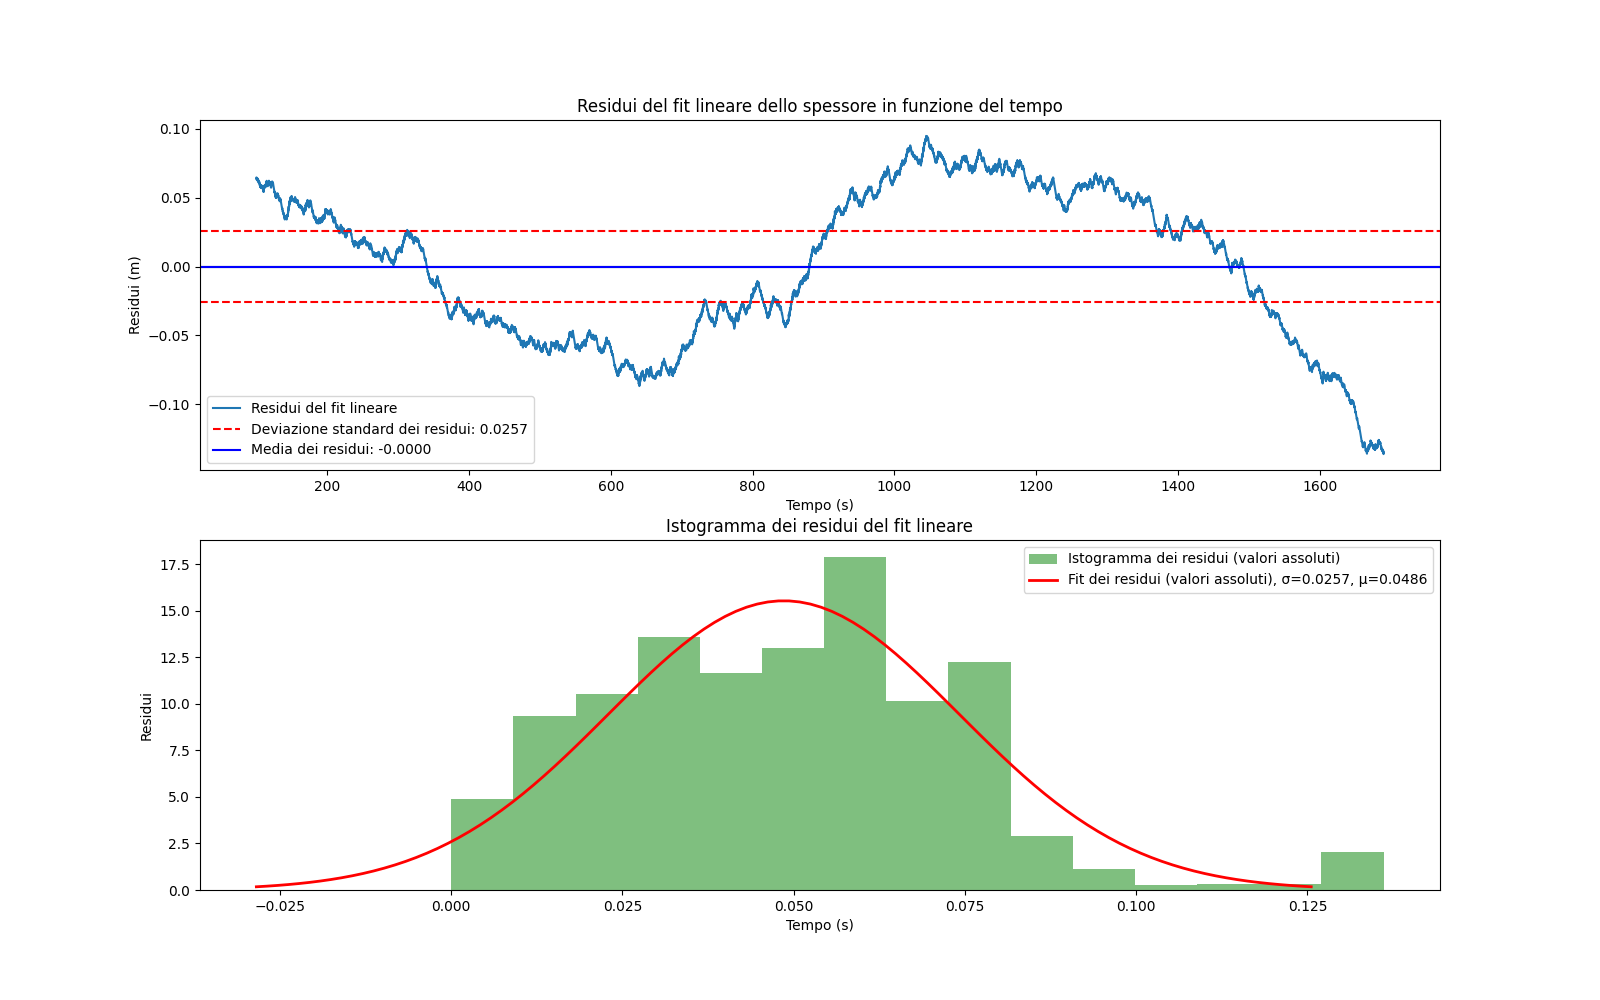

In [32]:
# plot dei residui del fit lineare, con deviazione standard dei residui
plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)

plt.title('Residui del fit lineare dello spessore in funzione del tempo')
plt.plot(bilancia_trel, fitted_rate_residues, label='Residui del fit lineare')

plt.axhline(fitted_rate_std, color='r', linestyle='--', label=f'Deviazione standard dei residui: {fitted_rate_std:.4f}')
plt.axhline(-fitted_rate_std, color='r', linestyle='--')

plt.axhline(0, color='k', linestyle='-')
plt.axhline(np.mean(fitted_rate_residues), color='b', linestyle='-', label=f'Media dei residui: {np.mean(fitted_rate_residues):.4f}')

plt.xlabel('Tempo (s)')
plt.ylabel('Residui (m)')
plt.legend()

plt.subplot(2, 1, 2)
plt.title('Istogramma dei residui del fit lineare')
plt.hist(abs(fitted_rate_residues), bins=15, density=True, alpha=0.5, label='Istogramma dei residui (valori assoluti)', color='g')

xs = np.linspace(-3*fitted_rate_std + fitted_rate_std_offset, 3*fitted_rate_std + fitted_rate_std_offset, 100)
ys = (1 / (fitted_rate_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((fitted_rate_std_offset - xs) / fitted_rate_std) ** 2)
plt.plot(xs, ys, color='r', label=f'Fit dei residui (valori assoluti), σ={fitted_rate_std:.4f}, μ={fitted_rate_std_offset:.4f}', linewidth=2)


plt.xlabel('Tempo (s)')
plt.ylabel('Residui')
plt.legend()
plt.show()

In [8]:
# ipotizzando rate distribuiti come una gaussiana attorno alla media
rates_mean = np.mean(bilancia_rates)
rates_std = np.std(bilancia_rates)

rates_distribution = lambda x, A=1: A * (1 / (rates_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - rates_mean) / rates_std) ** 2)    # fit della distribuzione dei rate come gaussiana, A è l'ampiezza della gaussiana | Normalizzazione della distribuzione dei rate

print(f"Media delle rate: {rates_mean:.2f}")
print(f"Deviazione standard delle rate: {rates_std:.2f}")

Media delle rate: 1.30
Deviazione standard delle rate: 0.65


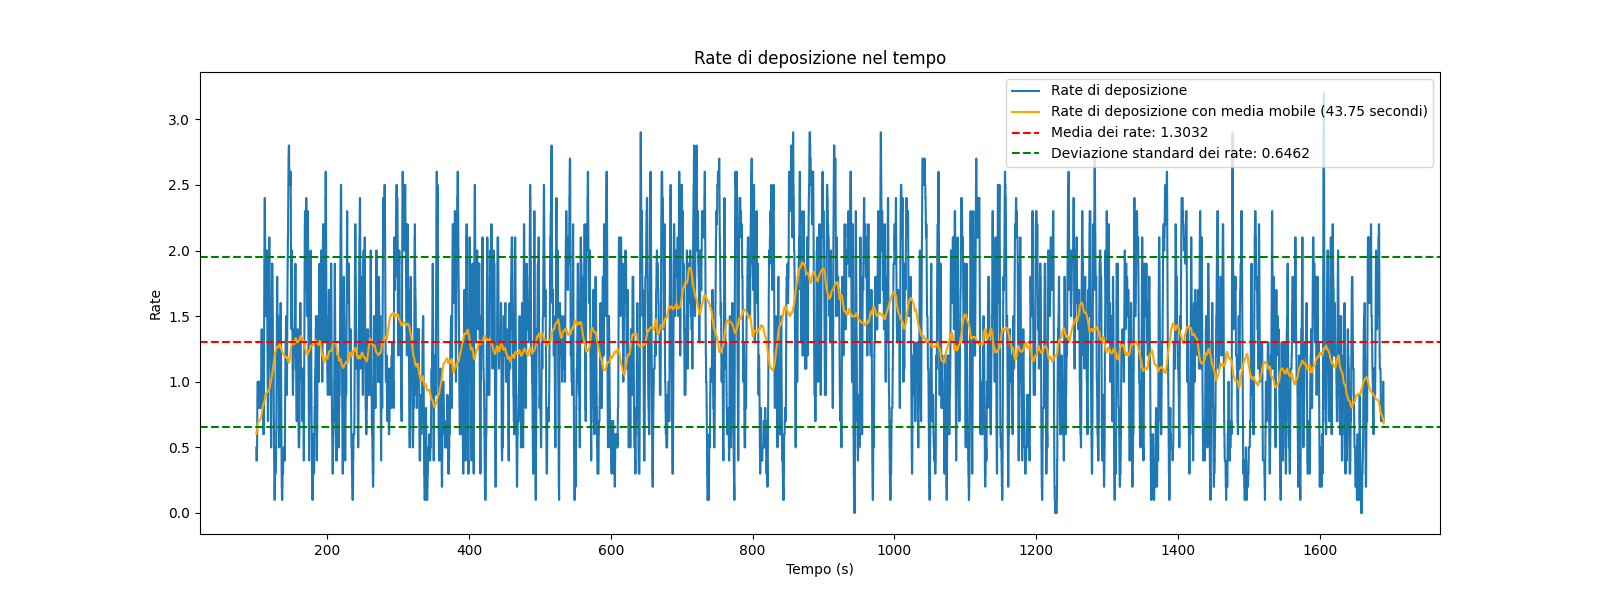

In [9]:
# plot del rate nel tempo
plt.figure(figsize=(16, 6))
plt.plot(bilancia_trel, bilancia_rates, label='Rate di deposizione')

window_size = 1000  # dimensione della finestra per la media mobile
avg_sample_rate = np.mean(np.diff(bilancia_trel))  # calcola il rate medio di campionamento
window_size_seconds = window_size * avg_sample_rate  # converte la dimensione della finestra in secondi
rate_smooth = signal.convolve(bilancia_rates, np.ones(window_size)/window_size, mode='same')  # media mobile per smoothing
plt.plot(bilancia_trel, rate_smooth, label=f'Rate di deposizione con media mobile ({window_size_seconds:.2f} secondi)', color='orange')

# media dei rate e deviazione standard
plt.axhline(rates_mean, color='r', linestyle='--', label=f'Media dei rate: {rates_mean:.4f}')
plt.axhline(rates_mean + rates_std, color='g', linestyle='--', label=f'Deviazione standard dei rate: {rates_std:.4f}')
plt.axhline(rates_mean - rates_std, color='g', linestyle='--')

plt.xlabel('Tempo (s)')
plt.ylabel('Rate')
plt.title('Rate di deposizione nel tempo')
plt.legend()
plt.show()

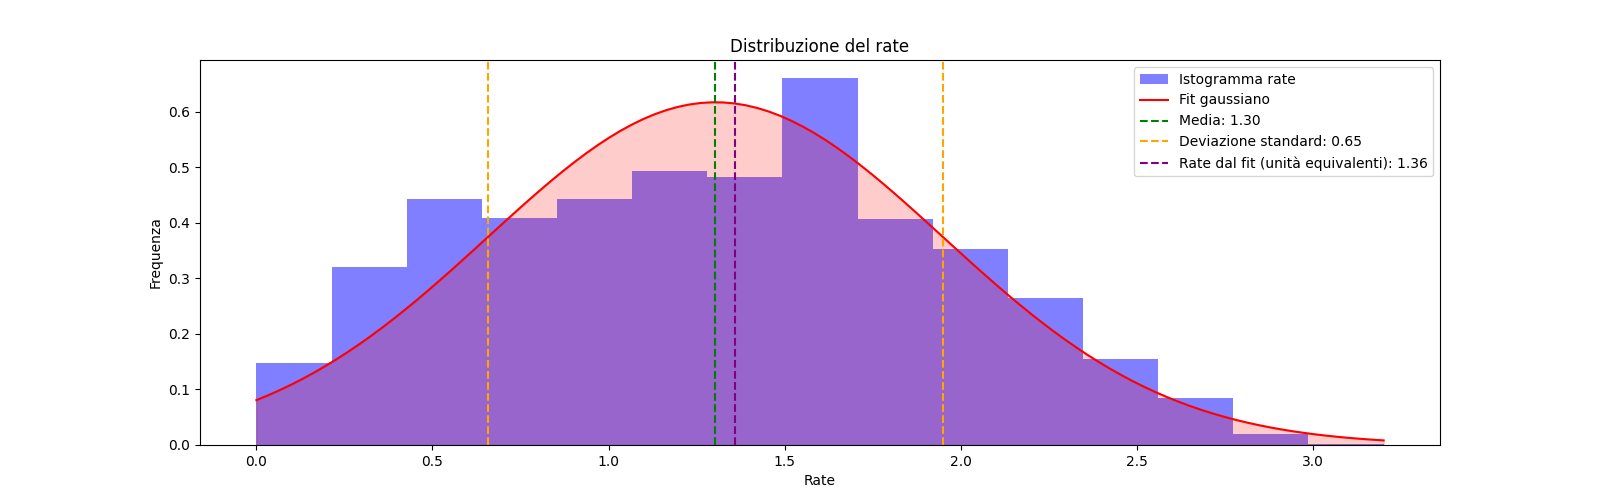

In [10]:
# plot dell'istogramma dei rate con fit gaussiano e confronto con risultati da spessore vs tempo e integrale dei rate

plt.figure(figsize=(16, 5))

# istogramma dei rate
plt.hist(bilancia_rates, bins=15, density=True, alpha=0.5, label='Istogramma rate', color='blue')

# fit gaussiano
xs = np.linspace(min(bilancia_rates), max(bilancia_rates), 100)
plt.plot(xs, rates_distribution(xs), label='Fit gaussiano', color='red')
plt.fill_between(xs, rates_distribution(xs), color='red', alpha=0.2)

# media e deviazione standard
plt.axvline(rates_mean, color='green', linestyle='--', label=f'Media: {rates_mean:.2f}')
plt.axvline(rates_mean + rates_std, color='orange', linestyle='--', label=f"Deviazione standard: {rates_std:.2f}")
plt.axvline(rates_mean - rates_std, color='orange', linestyle='--')

# rate da fit lineare spessore vs tempo
plt.axvline(fitted_rate * unit_m, color='purple', linestyle='--', label=f'Rate dal fit (unità equivalenti): {fitted_rate * unit_m:.2f}')

# deviazione dei residui del fit lineare
#plt.axvline(fitted_rate_std * unit_m, color='brown', linestyle='--', label=f'dev_std residui fit lineare: {fitted_rate_std * unit_m:.2f}')
#plt.axvline(-fitted_rate_std * unit_m, color='brown', linestyle='--')

plt.legend()
plt.xlabel('Rate')
plt.ylabel('Frequenza')
plt.title('Distribuzione del rate')

plt.show()


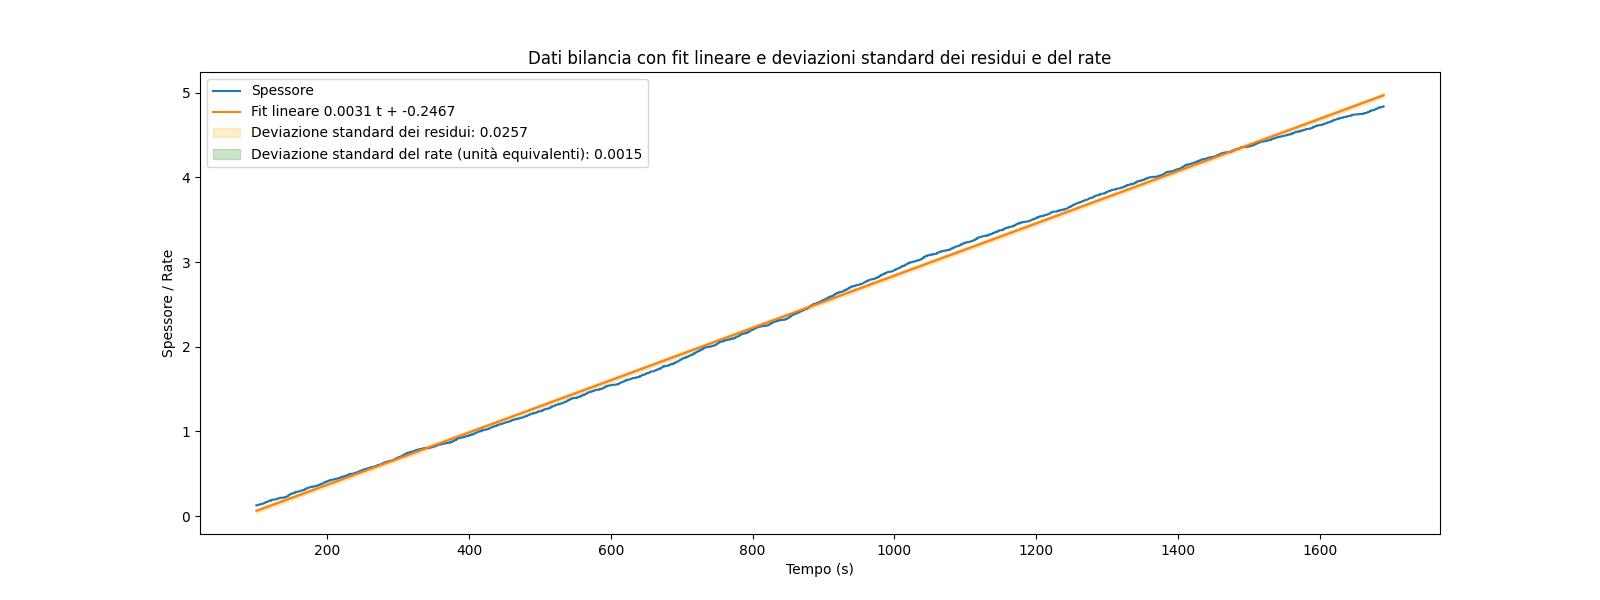

In [11]:
# plot del fit e dei dati, con dev std dei residui e con dev std del rate
plt.figure(figsize=(16, 6))

plt.plot(bilancia_trel, bilancia_thicknesses, label='Spessore')

plt.plot(bilancia_trel, spessori_func(bilancia_trel), label=f'Fit lineare {fitted_rate:.4f} t + {thickness_offset:.4f}')

residues_error_upper = spessori_func(bilancia_trel) + fitted_rate_std
residues_error_lower = spessori_func(bilancia_trel) - fitted_rate_std
plt.fill_between(bilancia_trel, residues_error_lower, residues_error_upper, color='orange', alpha=0.2, label=f'Deviazione standard dei residui: {fitted_rate_std:.4f}')

rate_variance_upper = spessori_func(bilancia_trel) + rates_std /unit_m
rate_variance_lower = spessori_func(bilancia_trel) - rates_std / unit_m
plt.fill_between(bilancia_trel, rate_variance_lower, rate_variance_upper, color='green', alpha=0.2, label=f'Deviazione standard del rate (unità equivalenti): {rates_std / unit_m:.4f}')

plt.xlabel('Tempo (s)')
plt.ylabel('Spessore / Rate')
plt.title('Dati bilancia con fit lineare e deviazioni standard dei residui e del rate')
plt.legend()
plt.show()

# Coverage?

Sto cercando di capire come il coverage (filling factor) dipenda dallo spessore medio del campione.

L'idea sarebbe di trovare la forma della funzione coverage(spessore) da dei semplici monte carlo, simulando la deposizione di particelle su un piano sotto diverse ipotesi.

In [12]:
# simulazioni monte carlo molto schematiche per vedere diverse funzioni spessore <-> coverage sotto diverse ipotesi

def spessore_campione(altezze):
    return np.mean(altezze)

def coverage_2d(altezze, soglia=0.5):
    return np.sum(altezze > soglia) / altezze.size


In [13]:
# deposizione di gaussiane troncate, con centro casuale e ampiezza casuale

def deposizione_gaussiana_troncata(altezze, centro, ampiezza, sigma):
    x = np.arange(altezze.shape[1])
    y = np.arange(altezze.shape[0])
    X, Y = np.meshgrid(x, y)
    gaussiana = ampiezza * np.exp(-((X - centro[0])**2 + (Y - centro[1])**2) / (2 * sigma**2))
    gaussiana[gaussiana < 0.01 * ampiezza] = 0  # troncamento della gaussiana
    altezze += gaussiana
    return altezze

altezze_gauss = np.zeros((1000, 1000))  # matrice di altezze inizializzata a zero

n_eventi = 1000  # numero di eventi di deposizione

ampiezze = np.random.uniform(0.1, 1.0, size=n_eventi)  # ampiezze casuali tra 0.1 e 1.0
centri = np.random.randint(0, 1000, size=(n_eventi, 2))  # centri casuali nella matrice
sigmas = np.random.uniform(10, 50, size=n_eventi)  # sigma casuali tra 10 e 50


spessori_medi_sim_gaussiane = []
coverage_sim_gaussiane = []
for i in range(n_eventi):
    altezze_gauss = deposizione_gaussiana_troncata(altezze_gauss, centri[i], ampiezze[i], sigmas[i])
    spessori_medi_sim_gaussiane.append(spessore_campione(altezze_gauss))
    coverage_sim_gaussiane.append(coverage_2d(altezze_gauss))

In [14]:
# lorenziane troncate, con centro casuale e ampiezza casuale

def deposizione_lorenziana_troncata(altezze, centro, ampiezza, gamma):
    x = np.arange(altezze.shape[1])
    y = np.arange(altezze.shape[0])
    X, Y = np.meshgrid(x, y)
    lorenziana = ampiezza * (gamma**2 / ((X - centro[0])**2 + (Y - centro[1])**2 + gamma**2))
    lorenziana[lorenziana < 0.01 * ampiezza] = 0  # troncamento della lorenziana
    altezze += lorenziana
    return altezze

altezze_lorenz = np.zeros((1000, 1000))  # matrice di altezze inizializzata a zero

centri_lorenz = np.random.randint(0, 1000, size=(n_eventi, 2))  # centri casuali nella matrice
ampiezze_lorenz = np.random.uniform(0.1, 1.0, size=n_eventi)  # ampiezze casuali tra 0.1 e 1.0
gammas = np.random.uniform(10, 50, size=n_eventi)  # gamma casuali tra 10 e 50

spessori_medi_sim_lorenziane = []
coverage_sim_lorenziane = []
for i in range(n_eventi):
    altezze_lorenz = deposizione_lorenziana_troncata(altezze_lorenz, centri_lorenz[i], ampiezze_lorenz[i], gammas[i])
    spessori_medi_sim_lorenziane.append(spessore_campione(altezze_lorenz))
    coverage_sim_lorenziane.append(coverage_2d(altezze_lorenz))


In [15]:
# cilindri casuali, con centro, raggio e ampiezza casuali

def deposizione_cilindro(altezze, centro, raggio, ampiezza):
    x = np.arange(altezze.shape[1])
    y = np.arange(altezze.shape[0])
    X, Y = np.meshgrid(x, y)
    distanza = np.sqrt((X - centro[0])**2 + (Y - centro[1])**2)
    cilindro = np.zeros_like(altezze)
    cilindro[distanza <= raggio] = ampiezza
    altezze += cilindro
    return altezze

altezze_cilindro = np.zeros((1000, 1000))  # matrice di altezze inizializzata a zero

centri_cilindro = np.random.randint(0, 1000, size=(n_eventi, 2))  # centri casuali nella matrice
raggi_cilindro = np.random.uniform(5, 50, size=n_eventi)
ampiezze_cilindro = np.random.uniform(0.1, 1.0, size=n_eventi)  # ampiezze casuali tra 0.1 e 1.0

spessori_medi_sim_cilindri = []
coverage_sim_cilindri = []
for i in range(n_eventi):
    altezze_cilindro = deposizione_cilindro(altezze_cilindro, centri_cilindro[i], raggi_cilindro[i], ampiezze_cilindro[i])
    spessori_medi_sim_cilindri.append(spessore_campione(altezze_cilindro))
    coverage_sim_cilindri.append(coverage_2d(altezze_cilindro))


In [16]:
# deposizione di singoli atomi. N atomi vengono depositati in posizioni casuali ad ogni step

def deposizione_singoli_atomi(altezze, n_atomi, ampiezza):
    x = np.random.randint(0, altezze.shape[1], size=n_atomi)
    y = np.random.randint(0, altezze.shape[0], size=n_atomi)
    altezze[y, x] += ampiezza
    return altezze

ampiezze = np.ones(n_eventi * 3) * 0.1  # ampiezza costante per tutti gli atomi
altezze_singoli_atomi = np.zeros((1000, 1000))
n_atomi = np.random.randint(100, 10000, size=n_eventi * 3)  # numero casuale di atomi da depositare ad ogni step

spessori_medi_sim_singoli_atomi = []
coverage_sim_singoli_atomi = []

for i in range(n_eventi * 3):  # più eventi per avere un coverage più alto
    altezze_singoli_atomi = deposizione_singoli_atomi(altezze_singoli_atomi, n_atomi[i], ampiezze[i])
    spessori_medi_sim_singoli_atomi.append(spessore_campione(altezze_singoli_atomi))
    coverage_sim_singoli_atomi.append(coverage_2d(altezze_singoli_atomi))


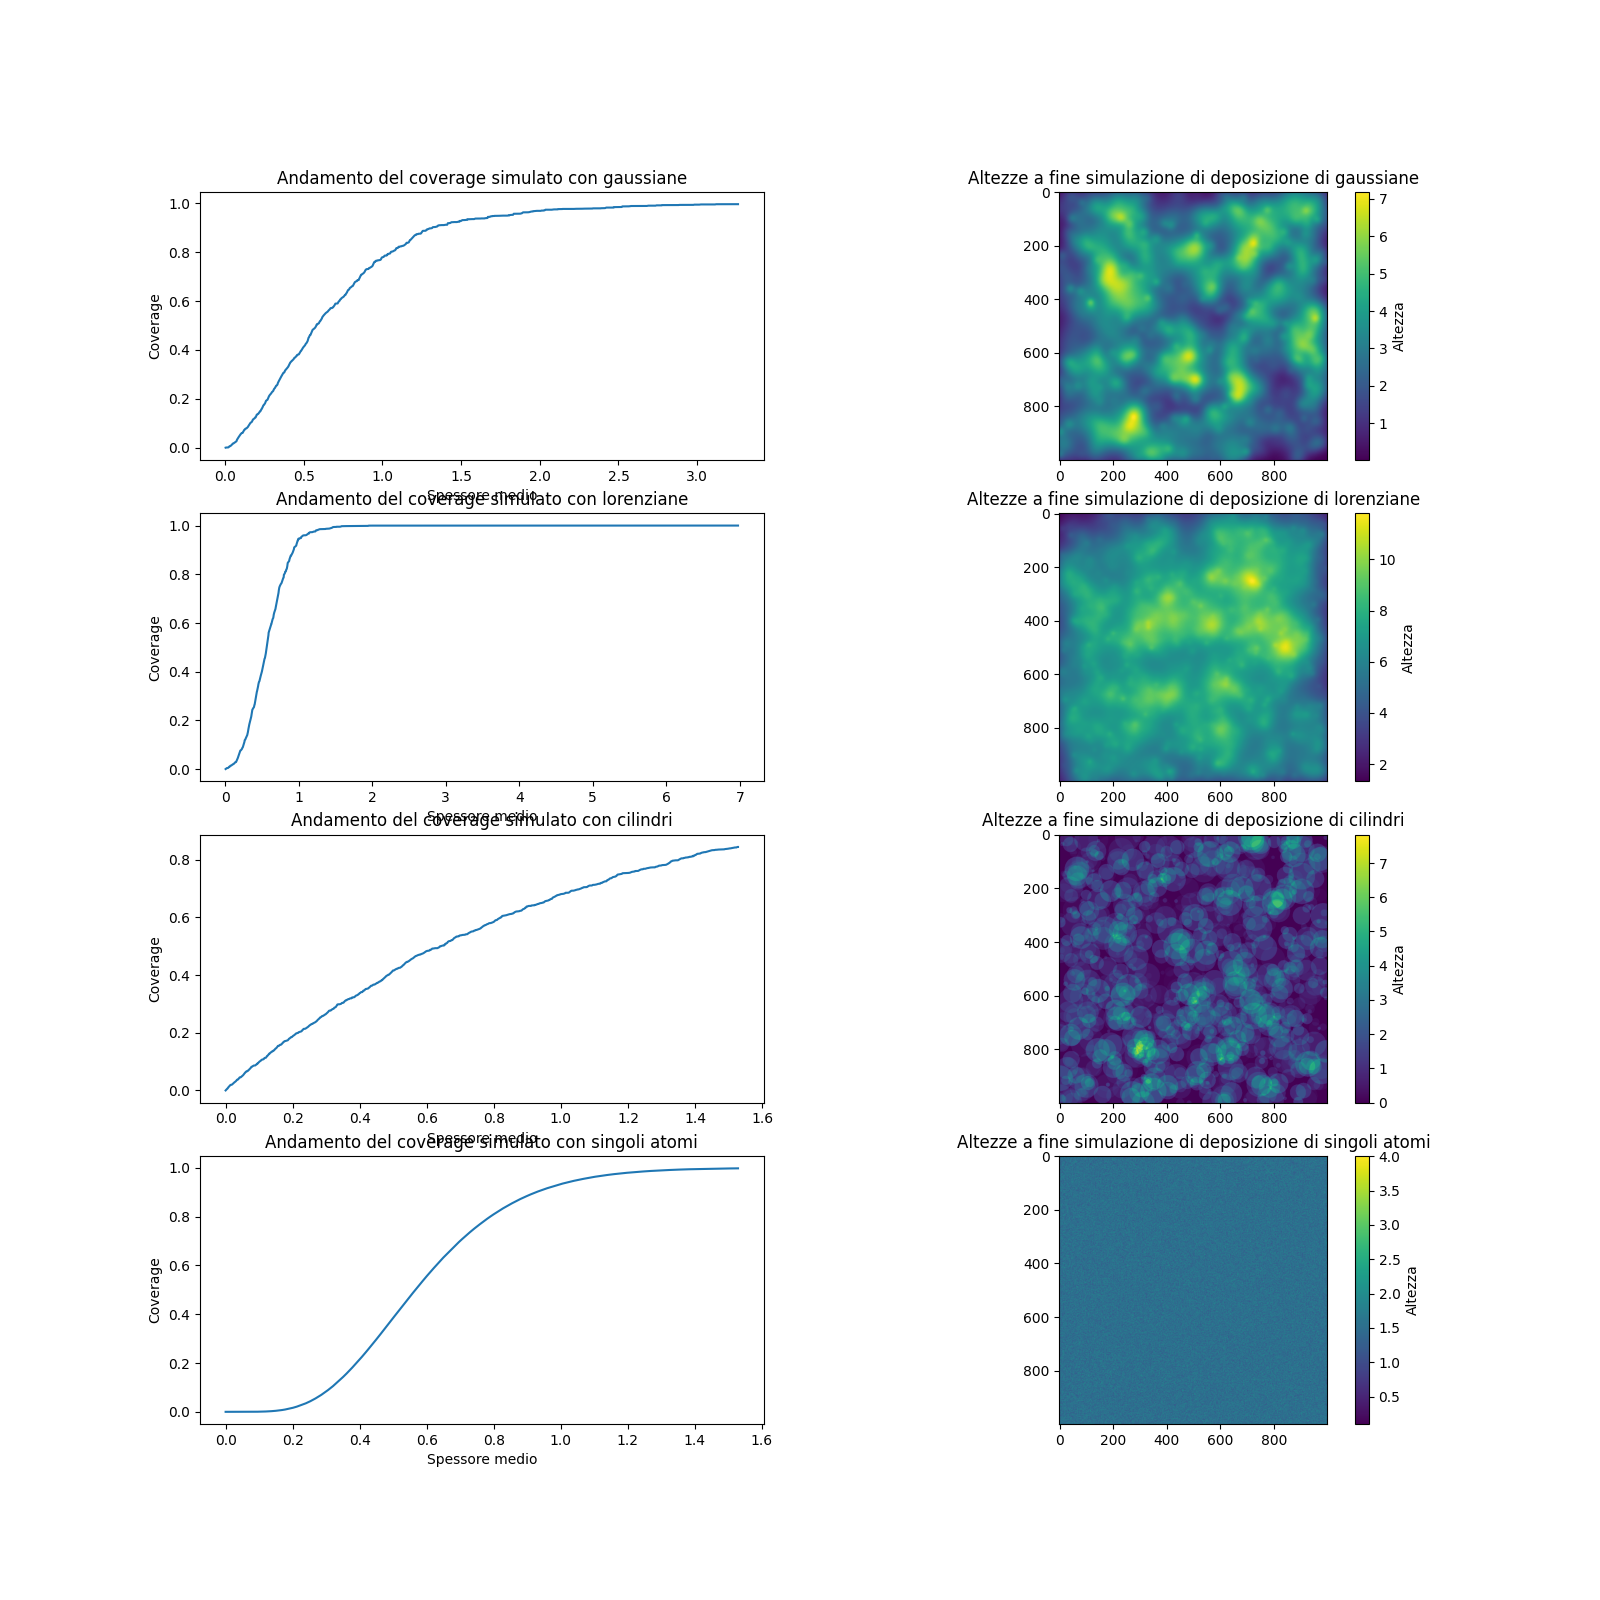

In [17]:
# plot dei risultati della simulazione di deposizione di gaussiane troncate, con spessore medio e coverage
plt.figure(figsize=(16, 16))

nrows, ncols = 4, 2
plt.subplot(nrows, ncols, 1)
#plt.plot(spessori_medi_sim_gaussiane, label='Spessore medio simulato con gaussiane')
plt.plot(spessori_medi_sim_gaussiane, coverage_sim_gaussiane, label='Andamento del coverage simulato con gaussiane')
plt.xlabel('Spessore medio')
plt.ylabel('Coverage')
plt.title('Andamento del coverage simulato con gaussiane')

plt.subplot(nrows, ncols, 2)
plt.imshow(altezze_gauss, cmap='viridis')
plt.colorbar(label='Altezza')
plt.title('Altezze a fine simulazione di deposizione di gaussiane')

plt.subplot(nrows, ncols, 3)
plt.plot(spessori_medi_sim_lorenziane, coverage_sim_lorenziane, label='Andamento del coverage simulato con lorenziane')
plt.xlabel('Spessore medio')
plt.ylabel('Coverage')
plt.title('Andamento del coverage simulato con lorenziane')

plt.subplot(nrows, ncols, 4)
plt.imshow(altezze_lorenz, cmap='viridis')
plt.colorbar(label='Altezza')
plt.title('Altezze a fine simulazione di deposizione di lorenziane')

plt.subplot(nrows, ncols, 5)
plt.plot(spessori_medi_sim_cilindri, coverage_sim_cilindri, label='Andamento del coverage simulato con cilindri')
plt.xlabel('Spessore medio')
plt.ylabel('Coverage')
plt.title('Andamento del coverage simulato con cilindri')

plt.subplot(nrows, ncols, 6)
plt.imshow(altezze_cilindro, cmap='viridis')
plt.colorbar(label='Altezza')
plt.title('Altezze a fine simulazione di deposizione di cilindri')

plt.subplot(nrows, ncols, 7)
plt.plot(spessori_medi_sim_singoli_atomi, coverage_sim_singoli_atomi, label='Andamento del coverage simulato con singoli atomi')
plt.xlabel('Spessore medio')
plt.ylabel('Coverage')
plt.title('Andamento del coverage simulato con singoli atomi')

plt.subplot(nrows, ncols, 8)
plt.imshow(altezze_singoli_atomi, cmap='viridis')
plt.colorbar(label='Altezza')
plt.title('Altezze a fine simulazione di deposizione di singoli atomi')

plt.show()


# Percolazione

In [18]:
'''elettrometro_dir = os.path.join(base_img_folder, folder_selector.value, 'data/points_keithley.txt')
keithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(elettrometro_dir)

keithley_currents = np.array(keithley_currents)
keithley_timestamps = np.array(keithley_timestamps)
keithley_trel = keithley_timestamps - keithley_timestamps[0]'''

"elettrometro_dir = os.path.join(base_img_folder, folder_selector.value, 'data/points_keithley.txt')\nkeithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(elettrometro_dir)\n\nkeithley_currents = np.array(keithley_currents)\nkeithley_timestamps = np.array(keithley_timestamps)\nkeithley_trel = keithley_timestamps - keithley_timestamps[0]"

In [19]:
'''auto_range_indices = np.array([i for i, r in enumerate(keithley_ranges) if r == -1])
plus2_inds = auto_range_indices - 1
plus1_inds = auto_range_indices - 2

elettrometro_masks = {
    "auto" : auto_range_indices,
    "+2" : plus2_inds,
    "+1" : plus1_inds
}

'''

'auto_range_indices = np.array([i for i, r in enumerate(keithley_ranges) if r == -1])\nplus2_inds = auto_range_indices - 1\nplus1_inds = auto_range_indices - 2\n\nelettrometro_masks = {\n    "auto" : auto_range_indices,\n    "+2" : plus2_inds,\n    "+1" : plus1_inds\n}\n\n'

In [20]:
'''# impostiamo a 0 i valori non sensati (NaN e molto grandi)
keithley_currents = np.nan_to_num(keithley_currents, nan=0.0, posinf=0.0, neginf=0.0)
keithley_trel = np.nan_to_num(keithley_trel, nan=0.0, posinf=0.0, neginf=0.0)

max_current = 1e-1  # Soglia massima di corrente (in A)
keithley_currents[np.abs(keithley_currents) > max_current] = 0.0'''

'# impostiamo a 0 i valori non sensati (NaN e molto grandi)\nkeithley_currents = np.nan_to_num(keithley_currents, nan=0.0, posinf=0.0, neginf=0.0)\nkeithley_trel = np.nan_to_num(keithley_trel, nan=0.0, posinf=0.0, neginf=0.0)\n\nmax_current = 1e-1  # Soglia massima di corrente (in A)\nkeithley_currents[np.abs(keithley_currents) > max_current] = 0.0'

In [21]:
'''# compute the median and the standard deviation of the current values between the 3 ranges

range_auto = keithley_currents[elettrometro_masks["auto"]]
range1 = keithley_currents[elettrometro_masks["+1"]]
range2 = keithley_currents[elettrometro_masks["+2"]]

# build an array where each element is (value auto, value +1, value +2) for each index in the auto range
terne = np.array([range1, range2, range_auto])

# compute the median and std_dev at each index
median = np.median(terne, axis=0)
std_dev = np.std(terne, axis=0)     # rivalutare. La std_dev di 3 valori ha poco senso, un'alternativa potrebbe essere dare un range con le differenze tra mediana e valori estremi (min e max)
'''

'# compute the median and the standard deviation of the current values between the 3 ranges\n\nrange_auto = keithley_currents[elettrometro_masks["auto"]]\nrange1 = keithley_currents[elettrometro_masks["+1"]]\nrange2 = keithley_currents[elettrometro_masks["+2"]]\n\n# build an array where each element is (value auto, value +1, value +2) for each index in the auto range\nterne = np.array([range1, range2, range_auto])\n\n# compute the median and std_dev at each index\nmedian = np.median(terne, axis=0)\nstd_dev = np.std(terne, axis=0)     # rivalutare. La std_dev di 3 valori ha poco senso, un\'alternativa potrebbe essere dare un range con le differenze tra mediana e valori estremi (min e max)\n'

In [22]:
'''def current_model(t, tc, A, p):
    """
    Modello della corrente in funzione di t (non ancora definito, può essere un tempo o altro).

    Prima di tc, il modello restituisce corrente=0.
    Dopo tc, il modello restituisce corrente=A*(t-tc)^p.

    Args:
        t (float or np.ndarray): Tempo o variabile indipendente.
        tc (float): Tempo di cutoff.
        A (float): Ampiezza della corrente.
        p (float): Esponente della potenza.
    
    Returns:
        float or np.ndarray: Valore della corrente calcolato secondo il modello.
    """

    # Convertiamo t in un array numpy per gestire sia scalari che array
    t = np.asarray(t)

    # Creiamo un array di zeri con la stessa forma di t
    current = np.zeros_like(t)

    # Applichiamo il modello solo per i valori di t maggiori di tc
    mask = t > tc
    current[mask] = A * (t[mask] - tc) ** p

    return current'''

'def current_model(t, tc, A, p):\n    """\n    Modello della corrente in funzione di t (non ancora definito, può essere un tempo o altro).\n\n    Prima di tc, il modello restituisce corrente=0.\n    Dopo tc, il modello restituisce corrente=A*(t-tc)^p.\n\n    Args:\n        t (float or np.ndarray): Tempo o variabile indipendente.\n        tc (float): Tempo di cutoff.\n        A (float): Ampiezza della corrente.\n        p (float): Esponente della potenza.\n    \n    Returns:\n        float or np.ndarray: Valore della corrente calcolato secondo il modello.\n    """\n\n    # Convertiamo t in un array numpy per gestire sia scalari che array\n    t = np.asarray(t)\n\n    # Creiamo un array di zeri con la stessa forma di t\n    current = np.zeros_like(t)\n\n    # Applichiamo il modello solo per i valori di t maggiori di tc\n    mask = t > tc\n    current[mask] = A * (t[mask] - tc) ** p\n\n    return current'

In [23]:
'''with plt.ioff():
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)

    ax.set_title("Corrente vs Tempo")
    ax.set_xlabel("Tempo (s)")
    ax.set_ylabel("Corrente (A)")

    line = ax.plot([], [], label="Dati Keithley", color='blue')[0]

    canvas = fig.canvas

xs = np.linspace(0, keithley_trel[-1], 1000)

param_names = ["tc", "A", "p"]
param_defaults = [0.0, 1e-6, 1.0]  # Valori iniziali per tc, A e p
param_ranges = [(0, np.max(keithley_trel)), (1e-9, 1e-3), (0.1, 5)]  # Intervalli per tc, A e p

param_selectors = [widgets.FloatSlider(value=default, min=range_[0], max=range_[1], step=(range_[1]-range_[0])/100, description=name) for name, default, range_ in zip(param_names, param_defaults, param_ranges)]

def update_plot(change):
    # Otteniamo i valori dei parametri dai selettori
    tc = param_selectors[0].value
    A = param_selectors[1].value
    p = param_selectors[2].value

    # Calcoliamo la corrente secondo il modello
    model_currents = current_model(xs, tc, A, p)

    # Aggiorniamo la linea del modello nel grafico
    line.set_data(xs, model_currents)
    #line.set_ydata(model_currents)
    
    # Aggiorniamo il titolo del grafico con i valori correnti dei parametri
    ax.set_title(f"Corrente vs Tempo (tc={tc:.2f}, A={A:.2e}, p={p:.2f})")

    ax.relim()  # Ricalcoliamo i limiti dell'asse
    ax.autoscale_view()  # Aggiorniamo la visualizzazione dell'asse
    
    # Ridisegniamo il canvas
    canvas.draw_idle()

update_plot(None)  # Inizializza il grafico con i valori di default

[selector.observe(update_plot, names='value') for selector in param_selectors]
[display(selector) for selector in param_selectors]
display(canvas)
'''


'with plt.ioff():\n    fig = plt.figure(figsize=(10, 6))\n    ax = fig.add_subplot(111)\n\n    ax.set_title("Corrente vs Tempo")\n    ax.set_xlabel("Tempo (s)")\n    ax.set_ylabel("Corrente (A)")\n\n    line = ax.plot([], [], label="Dati Keithley", color=\'blue\')[0]\n\n    canvas = fig.canvas\n\nxs = np.linspace(0, keithley_trel[-1], 1000)\n\nparam_names = ["tc", "A", "p"]\nparam_defaults = [0.0, 1e-6, 1.0]  # Valori iniziali per tc, A e p\nparam_ranges = [(0, np.max(keithley_trel)), (1e-9, 1e-3), (0.1, 5)]  # Intervalli per tc, A e p\n\nparam_selectors = [widgets.FloatSlider(value=default, min=range_[0], max=range_[1], step=(range_[1]-range_[0])/100, description=name) for name, default, range_ in zip(param_names, param_defaults, param_ranges)]\n\ndef update_plot(change):\n    # Otteniamo i valori dei parametri dai selettori\n    tc = param_selectors[0].value\n    A = param_selectors[1].value\n    p = param_selectors[2].value\n\n    # Calcoliamo la corrente secondo il modello\n    mod

In [24]:
'''plt.figure(figsize=(12, 8))

#plt.plot(keithley_trel, keithley_currents, label='Keithley', color='red', marker='o', markersize=3, linestyle='none')
for name, mask in elettrometro_masks.items():
    plt.plot(keithley_trel[mask], keithley_currents[mask], label=f'Keithley {name}', marker='o', markersize=3, linestyle='none')

#plt.errorbar(keithley_trel[elettrometro_masks["auto"]], median, yerr=std_dev, fmt='o', color='black', label='Median ± Std Dev')
plt.plot(keithley_trel[elettrometro_masks["auto"]], median, color='black', label='Median', linewidth=2)
plt.fill_between(keithley_trel[elettrometro_masks["auto"]], median - 2 * std_dev, median + 2 * std_dev, color='gray', alpha=0.5, label='95% Confidence Interval (±2σ)')

max_t = 2500
max_t_mask = keithley_trel[elettrometro_masks["auto"]] <= max_t
ts = keithley_trel[elettrometro_masks["auto"]][max_t_mask]
combined_data = median[max_t_mask]

plt.axvline(x=max_t, color='green', linestyle='--', label=f'Max Time = {max_t}s')

plt.xlabel('Tempo (s)')
plt.ylabel('Corrente (A)')
plt.title('Variazione della corrente nel tempo')
plt.legend()
plt.show()'''

'plt.figure(figsize=(12, 8))\n\n#plt.plot(keithley_trel, keithley_currents, label=\'Keithley\', color=\'red\', marker=\'o\', markersize=3, linestyle=\'none\')\nfor name, mask in elettrometro_masks.items():\n    plt.plot(keithley_trel[mask], keithley_currents[mask], label=f\'Keithley {name}\', marker=\'o\', markersize=3, linestyle=\'none\')\n\n#plt.errorbar(keithley_trel[elettrometro_masks["auto"]], median, yerr=std_dev, fmt=\'o\', color=\'black\', label=\'Median ± Std Dev\')\nplt.plot(keithley_trel[elettrometro_masks["auto"]], median, color=\'black\', label=\'Median\', linewidth=2)\nplt.fill_between(keithley_trel[elettrometro_masks["auto"]], median - 2 * std_dev, median + 2 * std_dev, color=\'gray\', alpha=0.5, label=\'95% Confidence Interval (±2σ)\')\n\nmax_t = 2500\nmax_t_mask = keithley_trel[elettrometro_masks["auto"]] <= max_t\nts = keithley_trel[elettrometro_masks["auto"]][max_t_mask]\ncombined_data = median[max_t_mask]\n\nplt.axvline(x=max_t, color=\'green\', linestyle=\'--\', la

In [25]:
'''def filling_factor_from_d(d, h_avg):
    """
    Calcola il filling factor (fattore di riempimento) a partire dallo spessore nominale d e dall'altezza media h_avg.
    La formula utilizzata è: filling_factor = (d / h_avg), dove d è lo spessore nominale e h_avg è l'altezza media.

    Args:
        d (float, nd_array): Spessore nominale.
        h_avg (float): Altezza media.

    Returns:
        (float, nd_array): Fattore di riempimento calcolato.
    """

    return d / h_avg

percolation_model = lambda d, h_avg, tc, A, p: current_model(filling_factor_from_d(d, h_avg), filling_factor_from_d(tc, h_avg), A, p)
'''

'def filling_factor_from_d(d, h_avg):\n    """\n    Calcola il filling factor (fattore di riempimento) a partire dallo spessore nominale d e dall\'altezza media h_avg.\n    La formula utilizzata è: filling_factor = (d / h_avg), dove d è lo spessore nominale e h_avg è l\'altezza media.\n\n    Args:\n        d (float, nd_array): Spessore nominale.\n        h_avg (float): Altezza media.\n\n    Returns:\n        (float, nd_array): Fattore di riempimento calcolato.\n    """\n\n    return d / h_avg\n\npercolation_model = lambda d, h_avg, tc, A, p: current_model(filling_factor_from_d(d, h_avg), filling_factor_from_d(tc, h_avg), A, p)\n'

In [26]:
'''def log_likelihood(theta, t, y, y_err):
    """
    Calcola il logaritmo della verosimiglianza (log-likelihood) per i dati osservati y in funzione dei parametri del modello theta.

    Uso una gaussiana centrata sui dati osservati y, con larghezza data dalla somma in quadratura degli errori y_err e della deviazione standard del modello.
    
    Args:
        theta (list): Lista dei parametri del modello [h_avg, tc, A, p, sigma].
        t (np.ndarray): Array dei tempi (o spessori) osservati.
        y (np.ndarray): Array delle correnti osservate.
        y_err (np.ndarray): Array degli errori associati alle correnti osservate.
    Returns:
        float: Valore del log-likelihood.
    """

    h_avg, tc, A, p, sigma = theta

    # Calcolo del modello predetto
    model_prediction = percolation_model(t, h_avg, tc, A, p)

    # calcolo gaussiana
    gaussian = -0.5 * np.sum(((y - model_prediction) / np.sqrt(y_err**2 + sigma**2))**2 + np.log(2 * np.pi * (y_err**2 + sigma**2)))

    return gaussian

def log_prior(theta):
    """
    Calcola il logaritmo della prior (log-prior) per i parametri del modello theta.

    Args:
        theta (list): Lista dei parametri del modello [h_avg, tc, A, p, sigma].
    Returns:
        float: Valore del log-prior.
    """

    h_avg, tc, A, p, sigma = theta

    # Definizione dei limiti dei parametri
    if not (0 < h_avg < 100 and 0 < tc < np.max(keithley_trel) and 0 < A < 10 and 0 < p < 5 and 0 < sigma < 10):
        return -np.inf  # Log-prior negativo infinito se i parametri sono fuori dai limiti

    return 0.0  # Log-prior zero se i parametri sono validi

def log_probability(theta, t, y, y_err):
    """
    Calcola il logaritmo della probabilità (log-probability) combinando il log-prior e il log-likelihood.

    Args:
        theta (list): Lista dei parametri del modello [d, h_avg, tc, A, p, sigma].
        t (np.ndarray): Array dei tempi (o spessori) osservati.
        y (np.ndarray): Array delle correnti osservate.
        y_err (np.ndarray): Array degli errori associati alle correnti osservate.
    Returns:
        float: Valore del log-probability.
    """

    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf  # Se il log-prior è negativo infinito, ritorniamo -inf

    ll = log_likelihood(theta, t, y, y_err)
    return lp + ll  # Somma del log-prior e del log-likelihood
'''

'def log_likelihood(theta, t, y, y_err):\n    """\n    Calcola il logaritmo della verosimiglianza (log-likelihood) per i dati osservati y in funzione dei parametri del modello theta.\n\n    Uso una gaussiana centrata sui dati osservati y, con larghezza data dalla somma in quadratura degli errori y_err e della deviazione standard del modello.\n    \n    Args:\n        theta (list): Lista dei parametri del modello [h_avg, tc, A, p, sigma].\n        t (np.ndarray): Array dei tempi (o spessori) osservati.\n        y (np.ndarray): Array delle correnti osservate.\n        y_err (np.ndarray): Array degli errori associati alle correnti osservate.\n    Returns:\n        float: Valore del log-likelihood.\n    """\n\n    h_avg, tc, A, p, sigma = theta\n\n    # Calcolo del modello predetto\n    model_prediction = percolation_model(t, h_avg, tc, A, p)\n\n    # calcolo gaussiana\n    gaussian = -0.5 * np.sum(((y - model_prediction) / np.sqrt(y_err**2 + sigma**2))**2 + np.log(2 * np.pi * (y_err**2 + 

In [27]:
'''num_samples = 20000  # Numero di campioni per MCMC
num_samplers = 32  # Numero di catene parallele per MCMC

initial_guesses = [1e-4, 0.0, 1e-6, 1.0, 1e-6]  # Valori iniziali per [h_avg, tc, A, p, sigma]
initial_positions = initial_guesses + 1e-4 * np.random.randn(num_samplers, len(initial_guesses))  # Posizioni iniziali per ogni catena

sampler = emcee.EnsembleSampler(num_samplers, len(initial_guesses), log_probability, args=(ts, combined_data, np.zeros_like(combined_data)))  # Passiamo un array di zeri come y_err, poiché non abbiamo errori specifici per i dati combinati
sampler.run_mcmc(initial_positions, num_samples, progress=True)

'''

'num_samples = 20000  # Numero di campioni per MCMC\nnum_samplers = 32  # Numero di catene parallele per MCMC\n\ninitial_guesses = [1e-4, 0.0, 1e-6, 1.0, 1e-6]  # Valori iniziali per [h_avg, tc, A, p, sigma]\ninitial_positions = initial_guesses + 1e-4 * np.random.randn(num_samplers, len(initial_guesses))  # Posizioni iniziali per ogni catena\n\nsampler = emcee.EnsembleSampler(num_samplers, len(initial_guesses), log_probability, args=(ts, combined_data, np.zeros_like(combined_data)))  # Passiamo un array di zeri come y_err, poiché non abbiamo errori specifici per i dati combinati\nsampler.run_mcmc(initial_positions, num_samples, progress=True)\n\n'

In [28]:
'''tau = sampler.get_autocorr_time(tol=0)
print(f"Autocorrelation time (tau): {tau}")

samples = sampler.get_chain(discard=int(10*max(tau)), thin=int(max(tau)), flat=True)  # Scartiamo i primi 2*tau campioni per burn-in

best_fit_params = np.median(samples, axis=0)
print("Best fit parameters (median of samples):")
print(f"h_avg: {best_fit_params[0]:.6e} m")
print(f"tc: {best_fit_params[1]:.6e} s")
print(f"A: {best_fit_params[2]:.6e} A")
print(f"p: {best_fit_params[3]:.6f}")
print(f"sigma: {best_fit_params[4]:.6e} ")
'''

'tau = sampler.get_autocorr_time(tol=0)\nprint(f"Autocorrelation time (tau): {tau}")\n\nsamples = sampler.get_chain(discard=int(10*max(tau)), thin=int(max(tau)), flat=True)  # Scartiamo i primi 2*tau campioni per burn-in\n\nbest_fit_params = np.median(samples, axis=0)\nprint("Best fit parameters (median of samples):")\nprint(f"h_avg: {best_fit_params[0]:.6e} m")\nprint(f"tc: {best_fit_params[1]:.6e} s")\nprint(f"A: {best_fit_params[2]:.6e} A")\nprint(f"p: {best_fit_params[3]:.6f}")\nprint(f"sigma: {best_fit_params[4]:.6e} ")\n'

In [29]:
'''print(f"Filling factor (d/h_avg) at the end: {filling_factor_from_d(keithley_trel[elettrometro_masks["auto"]][-1], best_fit_params[0]):.6f}")'''

'print(f"Filling factor (d/h_avg) at the end: {filling_factor_from_d(keithley_trel[elettrometro_masks["auto"]][-1], best_fit_params[0]):.6f}")'

In [30]:
'''import corner

# Creiamo il corner plot per visualizzare le distribuzioni dei parametri
labels = ["h_avg (m)", "tc (s)", "A (A)", "p", "sigma (A)"]
fig_corner = corner.corner(samples, labels=labels, truths=best_fit_params, show_titles=True, title_fmt=".2e", title_kwargs={"fontsize": 12})
'''

'import corner\n\n# Creiamo il corner plot per visualizzare le distribuzioni dei parametri\nlabels = ["h_avg (m)", "tc (s)", "A (A)", "p", "sigma (A)"]\nfig_corner = corner.corner(samples, labels=labels, truths=best_fit_params, show_titles=True, title_fmt=".2e", title_kwargs={"fontsize": 12})\n'

In [31]:
'''plt.figure(figsize=(12, 8))
plt.plot(keithley_trel[elettrometro_masks["auto"]], median, color='black', label='Median', linewidth=2)
plt.fill_between(keithley_trel[elettrometro_masks["auto"]], median - 2 * std_dev, median + 2 * std_dev, color='gray', alpha=0.5, label='95% Confidence Interval (±2σ)')

# Calcoliamo la corrente predetta dal modello usando i parametri migliori
model_currents_best_fit = percolation_model(keithley_trel[elettrometro_masks["auto"]], *best_fit_params[:-1])  # Escludiamo sigma
plt.plot(keithley_trel[elettrometro_masks["auto"]], model_currents_best_fit, color='red', label='Best Fit Model', linewidth=2)

plt.xlabel('Tempo (s)')
plt.ylabel('Corrente (A)')
plt.title('Variazione della corrente nel tempo con modello di percolazione')
plt.legend()
plt.show()'''

'plt.figure(figsize=(12, 8))\nplt.plot(keithley_trel[elettrometro_masks["auto"]], median, color=\'black\', label=\'Median\', linewidth=2)\nplt.fill_between(keithley_trel[elettrometro_masks["auto"]], median - 2 * std_dev, median + 2 * std_dev, color=\'gray\', alpha=0.5, label=\'95% Confidence Interval (±2σ)\')\n\n# Calcoliamo la corrente predetta dal modello usando i parametri migliori\nmodel_currents_best_fit = percolation_model(keithley_trel[elettrometro_masks["auto"]], *best_fit_params[:-1])  # Escludiamo sigma\nplt.plot(keithley_trel[elettrometro_masks["auto"]], model_currents_best_fit, color=\'red\', label=\'Best Fit Model\', linewidth=2)\n\nplt.xlabel(\'Tempo (s)\')\nplt.ylabel(\'Corrente (A)\')\nplt.title(\'Variazione della corrente nel tempo con modello di percolazione\')\nplt.legend()\nplt.show()'